In [ ]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
# set HF_HOME to a path with sufficient disk space
os.environ["HF_HOME"] = "/voyager-data/luoerpai/hf_cache/"
os.environ["HF_DATASETS_CACHE"]="/voyager-data/luoerpai/hf_cache/"

os.environ["PYARROW_NUM_THREADS"] = "190"     # or set a reasonable core count manually
os.environ["OMP_NUM_THREADS"] = "190"

import json
import torch
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import sys
import matplotlib.pyplot as plt
import torch.nn.functional as F
from cytotrace2_py.cytotrace2_py import *
from cytotrace2_py import read_file, process_with_scanpy

from scipy import stats
from tqdm import tqdm
import pickle
import random
import pyarrow.parquet as pq

from sklearn.decomposition import PCA
import umap

import scipy.sparse
import scvelo as scv
import cellrank as cr
from scipy.sparse import csr_matrix

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sys.path.append('..')
from src.utils.tokenizer import mixMulanTokenizer
from src.model.CellTempo_VQVAE.model import VQModel
from src.utils.distribution import NegativeBinomial
from src.utils.utils_metrics import *
from src.utils.utils_metrics import timecourse_markers_real_then_compare

In [ ]:
reference_gene = pd.read_csv('../src/utils/OS_scRNA_gene_index.18791.tsv',sep='\t')['gene_name'].values

metadata = pd.read_parquet("../data/sample_metadata.parquet")

with open('../data/size_factor.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

size_factor_dict = loaded_dict

with open('../data/cell_id_mapping_dict.json', 'r') as f:
    cell_name_to_num = json.load(f)

pretrained_model_path = '/hpc-cache-pfs/home/bianhaiyang/veloMulan/outputHub/vqvae_ckpt/cvqvae_scbasecount_26c24d_512n_new/checkpoint-700000/vqmodel'

model = VQModel.from_pretrained(pretrained_model_path,cvq_distance = 'cos',cvq_anchor='probrandom')#.cuda()

An error occurred while trying to fetch /hpc-cache-pfs/home/bianhaiyang/veloMulan/outputHub/vqvae_ckpt/cvqvae_scbasecount_26c24d_512n_new/checkpoint-700000/vqmodel: Error no file named diffusion_pytorch_model.safetensors found in directory /hpc-cache-pfs/home/bianhaiyang/veloMulan/outputHub/vqvae_ckpt/cvqvae_scbasecount_26c24d_512n_new/checkpoint-700000/vqmodel.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


# find a dataset

In [23]:
# all h5ad file in the testset of scBasetraj
mode = 'test'
table = pq.read_table(f'/voyager-data/luoerpai/scBaseCount/trajectory_{mode}.parquet')
trajectory_list = table['tokens']
testset = np.unique([traj[0].as_py().split('_')[0] for traj in trajectory_list])

Load data; download the corresponding h5ad file from scBaseCount first.

In [ ]:
srx_id = 'SRX12173016' #'SRX12173003' 'SRX11980210' 'SRX12173016'
os.makedirs(f'../outputs/generated/{srx_id}', exist_ok=True)

adata_test = sc.read_h5ad(f'/voyager-data/gaohx/scBaseCount/velocyto/{srx_id}.h5ad')
adata_test = map_adata_to_reference_genes(adata_test, reference_gene)
adata_test.X = (adata_test.layers['spliced'] + adata_test.layers['unspliced'] + adata_test.layers['ambiguous'])
adata_test

✅ 18791 genes matched, 0 missing from adata.


/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


AnnData object with n_obs × n_vars = 8252 × 18791
    obs: 'gene_count', 'umi_count', 'SRX_accession'
    var: 'gene_ids', 'feature_types'
    layers: 'ambiguous', 'spliced', 'unspliced'

Compute CytoTRACE

In [25]:
# assume adata.X is a csr_matrix
X = adata_test.X.T   # transpose: genes × cells
if not scipy.sparse.issparse(X):
    X = scipy.sparse.csr_matrix(X)

# open file stream for writing
with open(f"../outputs/generated/{srx_id}/scRNA_expression_{srx_id}.txt", "w") as f:
    # write header (cell names)
    header = "Gene\t" + "\t".join(adata_test.obs_names)
    f.write(header + "\n")

    # write row by row (avoid converting to dense all at once)
    for i, g in enumerate(adata_test.var_names):
        row = X.getrow(i).toarray().ravel()
        line = g + "\t" + "\t".join(map(str, row))
        f.write(line + "\n")

cytotrace2: Input parameters
    Input file: ../outputs/generated/SRX12173016/scRNA_expression_SRX12173016.txt
    Species: human
    Parallelization enabled: True
    Batch size: 20000
    Smoothing batch size: 1000
    Seed: 14
    Output directory: tmp
    Plotting enabled: True
    Verbose mode enabled: True
    User-provided limit for number of cores to use: None
       ...113 cores detected. CytoTRACE 2 will run using up to 56/113 cores.
cytotrace2: Loading dataset
cytotrace2: Dataset characteristics
    Number of input genes:  18791
    Number of input cells:  8252
cytotrace2: Computing UMAP embeddings from full expression


/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.C

cytotrace2: The passed batch_size is greater than the number of cells in the subsample. 
    Now setting batch_size to 8252.
cytotrace2: Preprocessing
cytotrace2: Running 1 prediction batch(es) sequentially using 20 cores per batch.
cytotrace2: Initiated processing batch 1/1 with 8252 cells
    Mapped 13883 input gene names to mouse orthologs
    13882 input genes are present in the model features.
cytotrace2: Performing initial model prediction
cytotrace2: Performing smoothing by diffusion
cytotrace2: Performing smoothing by adaptive KNN


... storing 'CytoTRACE2_Potency' as categorical
... storing 'preKNN_CytoTRACE2_Potency' as categorical
maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 31 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'M', 'O', 'P', 'R', 'T', 'U', 'a', 'c', 'd', 'e', 'f', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 'space', 't', 'two', 'u', 'y']
Glyph IDs:   [0, 1, 2, 3, 20, 21, 36, 38, 39, 40, 48, 50, 51, 53, 55, 56, 68, 70, 71, 72, 73, 74, 76, 79, 81, 82, 83, 85, 87, 88, 92]
Closed glyph list over 'GSUB': 36 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'M', 'O', 'P', 'R', 'T', 'U', 'a', 'c', 'd', 'e', 'f', 'fi', 'fl', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 'space', 't', 'two', 'u', 'uniFB00', 'uniFB03', 'uniFB04', 'y']
Glyph IDs:   [0, 1, 2, 3, 20, 21, 36, 38, 39, 40, 48, 50, 51, 53,

cytotrace2: Plotting outputs


hmtx subsetted
cmap subsetted
fpgm subsetting not needed
prep subsetting not needed
cvt  subsetting not needed
loca subsetting not needed
post subsetted
gasp subsetting not needed
MATH subsetted
GDEF subsetted
GPOS subsetted
GSUB subsetted
name subsetting not needed
glyf subsetted
head pruned
OS/2 Unicode ranges pruned: [0]
OS/2 CodePage ranges pruned: [0]
glyf pruned
GDEF pruned
GPOS pruned
GSUB pruned
name pruned
maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 32 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'M', 'O', 'P', 'R', 'T', 'U', 'a', 'c', 'd', 'e', 'f', 'g', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'space', 't', 'two', 'u', 'y']
Glyph IDs:   [0, 1, 2, 3, 20, 21, 36, 38, 39, 40, 48, 50, 51, 53, 55, 56, 68, 70, 71, 72, 73, 74, 76, 79, 81, 82, 83, 85, 86, 87, 88, 92]
Closed glyph list over 'GSUB': 37 

cytotrace2: Finished.


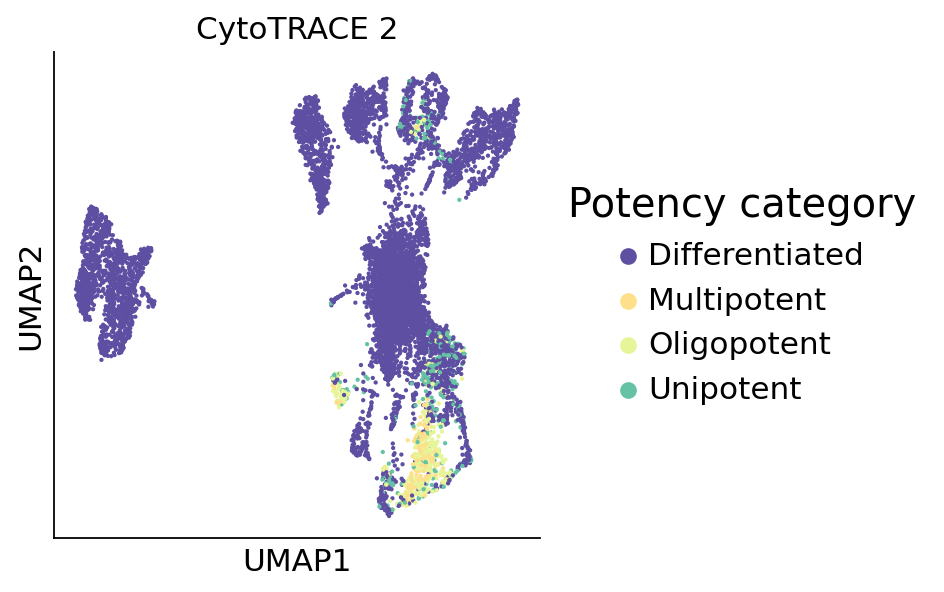

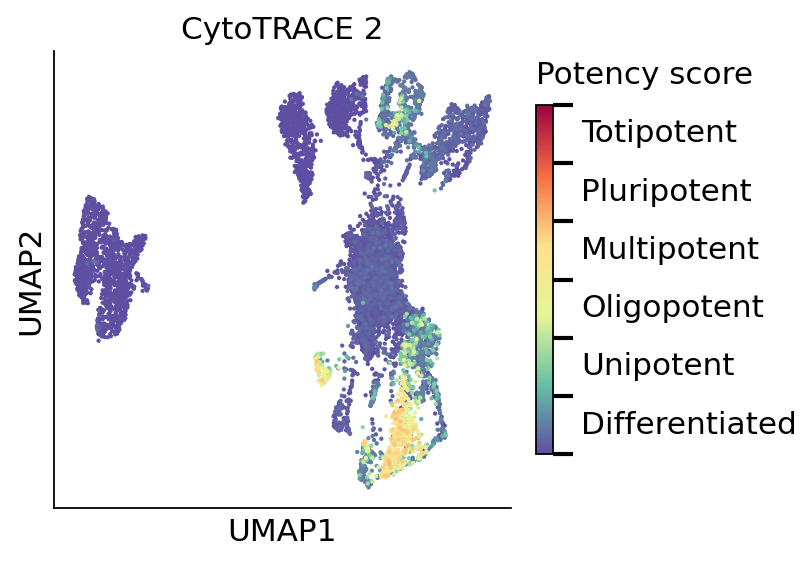

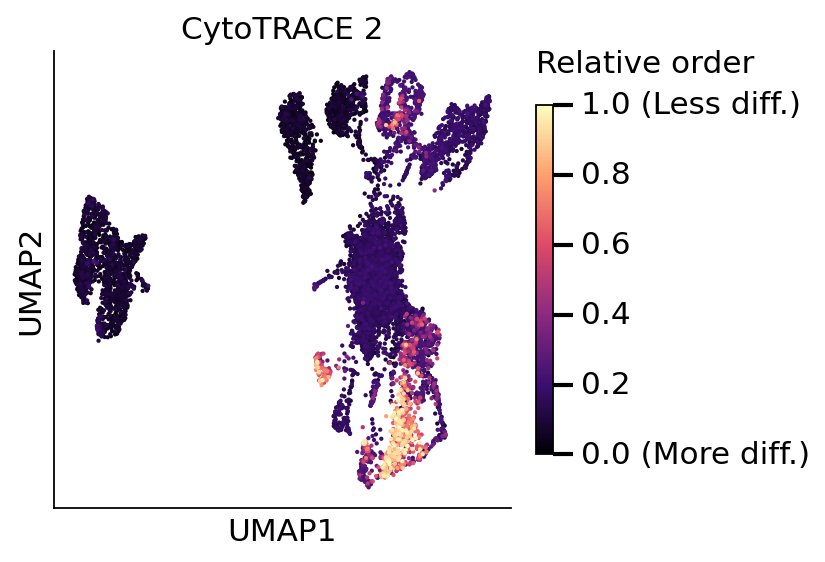

In [26]:
input_path = f"../outputs/generated/{srx_id}/scRNA_expression_{srx_id}.txt"
example_species = "human"

results_cyto, tmp = cytotrace2(input_path,
                     species=example_species,
                     output_dir='tmp')

adata_test.obs["pseudotime"] = 1 - results_cyto['CytoTRACE2_Score']

Compute CellRank

/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
... storing 'preKNN_CytoTRACE2_Potency' as categorical


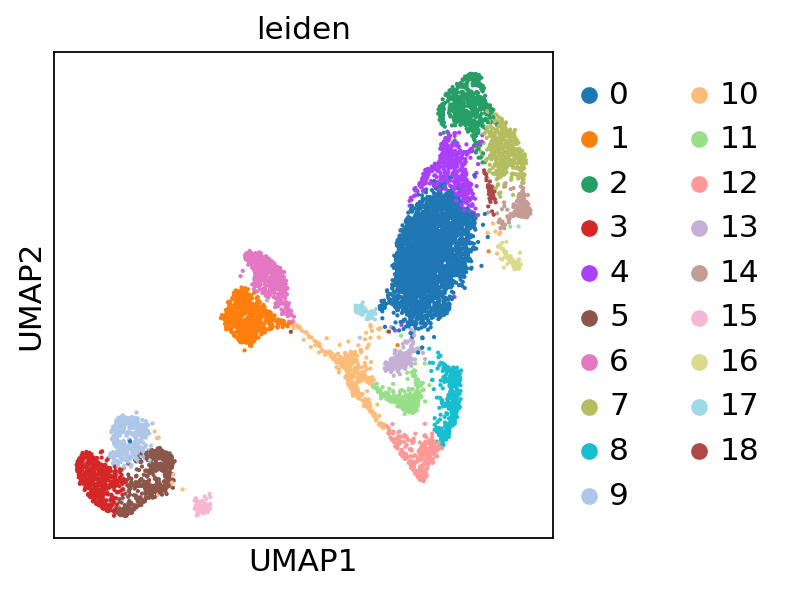

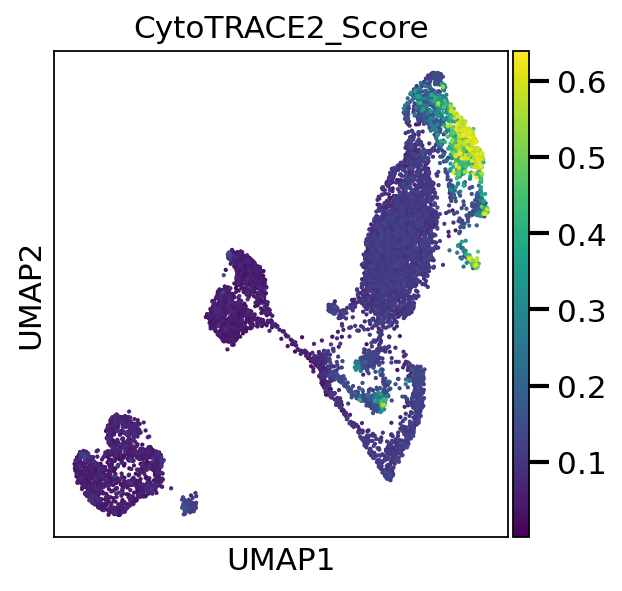

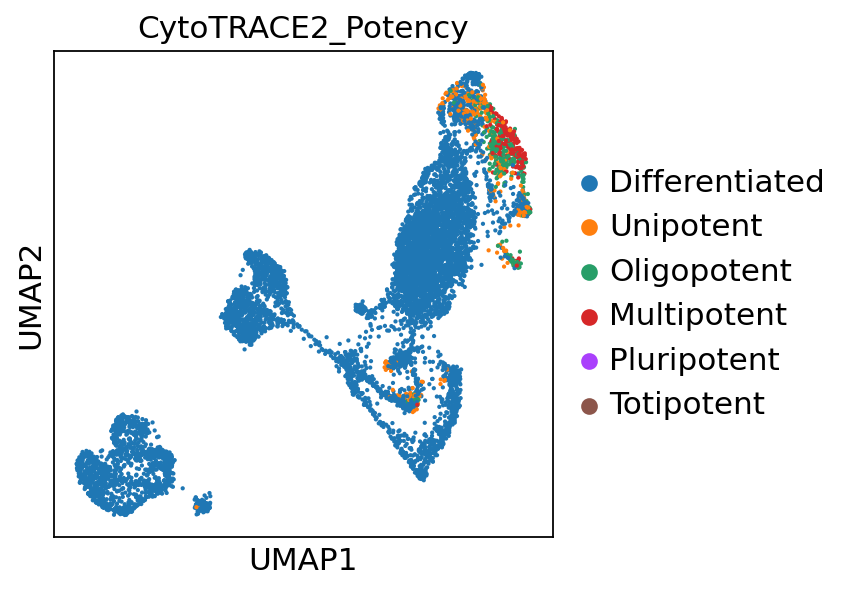

Normalized count data: spliced, unspliced.
computing moments based on connectivities
    finished (0:00:08) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:03) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/113 cores)


  0%|          | 0/8252 [00:00<?, ?cells/s]

    finished (0:00:39) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


  0%|          | 0/8252 [00:00<?, ?cell/s]

  0%|          | 0/8252 [00:00<?, ?cell/s]

computing velocity embedding
    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/root/miniconda3/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/root/miniconda3/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/root/miniconda3/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/root/miniconda3/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dt

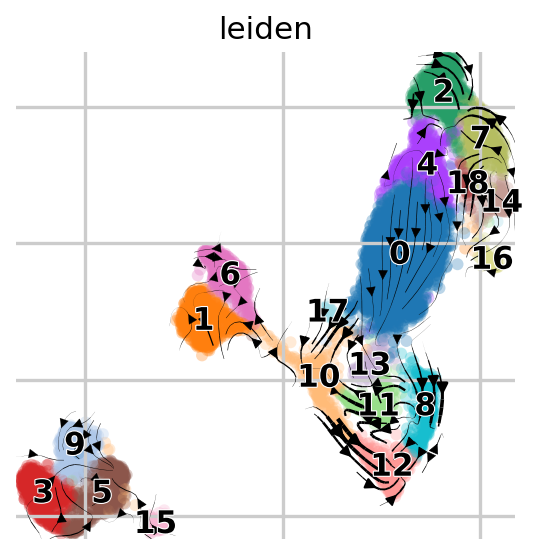

In [27]:
# Preprocessing
adata = adata_test.copy()
adata.raw = adata
# sc.pp.filter_cells(adata, min_counts=500)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.calculate_qc_metrics(adata, inplace=True)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata)

# Clustering & UMAP
sc.pp.neighbors(adata, use_rep='X_pca', n_neighbors=50)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1.0)

# Save UMAP figure
for col in results_cyto.columns:
    adata.obs[col] = results_cyto.loc[adata.obs_names, col].values
p = sc.pl.umap(adata, color=['leiden'], return_fig=True)
sc.pl.umap(adata, color=['CytoTRACE2_Score'])
sc.pl.umap(adata, color=['CytoTRACE2_Potency'])

# Velocity
scv.pp.normalize_per_cell(adata)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
# scv.tl.velocity(adata)
scv.tl.velocity(adata, mode="deterministic")
scv.tl.velocity_graph(adata)
scv.tl.velocity_confidence(adata)

# Cellrank
vk = cr.kernels.VelocityKernel(adata)
vk.compute_transition_matrix()
adata.obsp['cr_velo_graph'] = vk.transition_matrix

# Save velocity stream figure
scv.pl.velocity_embedding_stream(
    adata, basis='umap', color='leiden',
)

Build trajectories

In [28]:
pseudotime=1-results_cyto['CytoTRACE2_Score'].values
T = adata.obsp['cr_velo_graph'].toarray()
T = csr_matrix(T)

adata.obs["pseudotime"]=pseudotime
# find the cluster with the smallest pseudotime
min_cluster = (
    adata.obs.groupby("leiden")["pseudotime"]
    .mean()   # or median(); change as needed
    .idxmin()
)

all_traj = []
selected_ids = []
start_point = []

for idx in range(adata.shape[0]):
    trajectory = sample_trajectory(T, start_cell=idx, max_steps=27, random_state=48, pseudotime=pseudotime, tol=1e-2)
    if len(trajectory) < 15:
        continue
    selected_ids.append(idx)
    start_point.append(trajectory[0])
    all_traj.append(trajectory[::3])

# select top 150 cells with smallest pseudotime
selected_traj = np.argsort(adata.obs["pseudotime"][start_point].values)[:150]
all_traj = [all_traj[i] for i in selected_traj]
print(len(all_traj))

150


Save the 150 cells with the smallest pseudotime as trajectory starting points. See scripts/generator_traj.sh.

In [29]:
adata_subset = adata_test[selected_ids].copy()
adata_subset.write_h5ad(f'../outputs/generated/{srx_id}/{srx_id}_selected_150.h5ad')
adata_subset

/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


AnnData object with n_obs × n_vars = 4908 × 18791
    obs: 'gene_count', 'umi_count', 'SRX_accession', 'pseudotime'
    var: 'gene_ids', 'feature_types'
    layers: 'ambiguous', 'spliced', 'unspliced'

Ground-truth trajectories for these 150 cells

In [30]:
# choose whether to use first or last occurrence
# grouped_nonempty, steps_sorted, pos_map = group_by_step_unique_first(all_traj)
grouped_nonempty, steps_sorted, pos_map = group_by_step_unique_last(all_traj)

# concatenate all cells in step order
adata_step_list = []
time_step_list = []

for step_idx, cell_ids in zip(steps_sorted, grouped_nonempty):
    # ensure order: one sub-AnnData per step, then concat
    adata_step_list.append(adata_test[cell_ids].copy())
    time_step_list.extend([step_idx] * len(cell_ids))

import anndata as ad

adata_traj_gt = ad.concat(adata_step_list, axis=0)

# assign the original step index as time_step for each cell
adata_traj_gt.obs["time_step"] = time_step_list
adata_traj_gt.obs["time_step_str"] = [f"step_{s}" for s in time_step_list]
adata_traj_gt

/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/merge.py:217: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(dtype):


AnnData object with n_obs × n_vars = 624 × 18791
    obs: 'gene_count', 'umi_count', 'SRX_accession', 'pseudotime', 'time_step', 'time_step_str'
    layers: 'ambiguous', 'spliced', 'unspliced'

Generated trajectory data

In [31]:
results = []
for i in range(1):
    results.extend(torch.load(f"/hpc-cache-pfs/home/bianhaiyang/veloMulan/outputHub/trajectory/scbasecount_traj_test_final/{srx_id}_top100.h5ad/gpu_{i}_results_big_2624_10000_1to10_{srx_id}.pt"))
    
with open('/hpc-cache-pfs/home/bianhaiyang/veloMulan/dataHub/scBaseCount_scvelo_rowcount_filtered/mix_meta_info_vq_traj.json', 'r') as f:
    meta_info = json.load(f)

__chars = meta_info['token_set']
vocab_size = len(__chars)
tokenizer = mixMulanTokenizer(__chars)

In [32]:
# autoregressive traj

time_step = 9
traj_list = []
gt_list = []
# prefix_num is the number of cells fed to the model
for prefix_num in range(0,time_step):

    size_factor = []
    cell_id = []
    exp_gen = []
    gene_names = []
    gene_ids = []
    ori_exp_curr = []
    ori_exp_next = []
    entropy = []
    for id, point in tqdm(enumerate(results)):
        c2_start = (model.num_code+3)*prefix_num+2 #point['c2_start']
        gene_name = tokenizer.decode(point['generated_ids'][c2_start:]).split('##')

        try:
            gene_id = [int(name) for name in gene_name[:model.num_code]]
        except:
            print(gene_name[:model.num_code])
            continue
        
        gene_ids.append(gene_id)
        
        codes = model.quantize.embedding.weight[gene_id]
        quant = codes.reshape(-1)
        expr = model.decoder(quant)

        exp_gen.append(expr)
        cell_name = trajectory_list[point['idx']].as_py()[prefix_num]  # cell id at the next time step
        
        cell_id.append(cell_name)
        
        tissue = metadata[metadata['srx_accession']==srx_id]['tissue'].values[0]    
        size_factor.append(loaded_dict[tissue])
        ori_exp_next.append(point['token_labels'])
        ori_exp_curr.append(point['expr_labels'])
        entropy.append(point['entropy'])

    reconstruct = torch.stack(exp_gen)
    size_factor = torch.tensor(size_factor)#.cuda()
    fmap = F.softmax(reconstruct, dim=-1) * size_factor.unsqueeze(-1) #real_cell_ori.sum(1).unsqueeze(-1) # #2000
    distr = NegativeBinomial(mu=fmap, theta=torch.exp(model.theta))
    reconstruct = distr.sample_ori().detach().cpu().numpy()
    # reconstruct.shape
    traj_list.append(reconstruct)
    gt_list.append(cell_id)


100it [00:01, 87.84it/s]
100it [00:01, 89.02it/s]
100it [00:01, 90.37it/s]
100it [00:01, 89.21it/s]
100it [00:01, 93.40it/s]
100it [00:01, 93.52it/s]
100it [00:01, 96.81it/s]
100it [00:00, 101.09it/s]
100it [00:00, 103.10it/s]


In [33]:
generate_all = np.concatenate(traj_list)
adata_gen = ad.AnnData(generate_all, )
adata_gen.var_names = reference_gene
adata_gen.obs_names = [f'cell_{i}' for i in range(adata_gen.shape[0])]
adata_gen.obs['time_step'] = np.concatenate([[i]*traj_list[0].shape[0] for i in range(0,time_step)])
adata_gen.obs['time_step_str'] = np.concatenate([[f'step_{str(i)}']*traj_list[0].shape[0] for i in range(0,time_step)])
adata_gen.obs['entropy'] = [0]*traj_list[0].shape[0] + list(np.stack(entropy).transpose(1,0)[:time_step-1].reshape(-1))
adata_gen

AnnData object with n_obs × n_vars = 900 × 18791
    obs: 'time_step', 'time_step_str', 'entropy'

Remove generation noise

In [ ]:
adata_generated = adata_gen.copy()
sc.pp.normalize_total(adata_generated)
sc.pp.log1p(adata_generated)
# sc.pp.highly_variable_genes(adata_generated)
sc.pp.scale(adata_generated)
sc.pp.pca(adata_generated)
sc.pp.neighbors(adata_generated)
sc.tl.umap(adata_generated)
mask = largest_umap_component_mask(adata_generated, step_key="time_step", step0_value=0)
adata_gen = adata_gen[mask]
adata_gen

/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


View of AnnData object with n_obs × n_vars = 900 × 18791
    obs: 'time_step', 'time_step_str', 'entropy'

# pseudotime correlation

Compute CytoTRACE

Ground truth

In [37]:
# assume adata.X is a csr_matrix
X = adata_traj_gt.X.T   # transpose: genes × cells
if not scipy.sparse.issparse(X):
    X = scipy.sparse.csr_matrix(X)

# open file stream for writing
with open(f"../outputs/generated/{srx_id}/scRNA_expression_{srx_id}_traj_gt.txt", "w") as f:
    # write header (cell names)
    header = "Gene\t" + "\t".join(adata_traj_gt.obs_names.values)
    f.write(header + "\n")

    # write row by row (avoid converting to dense all at once)
    for i, g in enumerate(adata_traj_gt.var_names):
        row = X.getrow(i).toarray().ravel()
        line = g + "\t" + "\t".join(map(str, row))
        f.write(line + "\n")

col = "time_step_str"

# build DataFrame
df = pd.DataFrame({
    "cell_id": adata_traj_gt.obs_names.values,
    "phenotype": adata_traj_gt.obs[col].values
})

# save as tab-separated txt
df.to_csv(f"../outputs/generated/{srx_id}/cell_annotation_{srx_id}_traj_gt.tsv", sep="\t", index=False)


cytotrace2: Input parameters
    Input file: ../outputs/generated/SRX12173016/scRNA_expression_SRX12173016_traj_gt.txt
    Species: human
    Parallelization enabled: True
    Batch size: 20000
    Smoothing batch size: 1000
    Seed: 28
    Output directory: ../outputs/generated/SRX12173016/gt
    Plotting enabled: True
    Verbose mode enabled: True
    User-provided limit for number of cores to use: None
       ...113 cores detected. CytoTRACE 2 will run using up to 56/113 cores.
cytotrace2: Loading dataset
cytotrace2: Dataset characteristics
    Number of input genes:  18791
    Number of input cells:  624
cytotrace2: Computing UMAP embeddings from full expression


/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.C

cytotrace2: The passed batch_size is greater than the number of cells in the subsample. 
    Now setting batch_size to 624.
cytotrace2: Preprocessing
cytotrace2: The number of cells in your dataset is less than the specified smoothing batch size.

    Model prediction will not be parallelized.
cytotrace2: Running 1 prediction batch(es) sequentially using 1 cores per batch.
cytotrace2: Initiated processing batch 1/1 with 624 cells
    Mapped 13883 input gene names to mouse orthologs
    13882 input genes are present in the model features.
cytotrace2: Performing initial model prediction
cytotrace2: Performing smoothing by diffusion
The passed subsample size is greater than the number of cells in the subsample. 
    Now setting subsample size to 624. 
cytotrace2: Performing smoothing by adaptive KNN


... storing 'phenotype' as categorical
... storing 'phenotype_txtwrap' as categorical
... storing 'preKNN_CytoTRACE2_Potency' as categorical
maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 26 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'e', 'eight', 'five', 'four', 'h', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 48, 51, 56, 66, 72, 75, 81, 82, 83, 86, 87, 92]
Closed glyph list over 'GSUB': 26 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'e', 'eight', 'five', 'four', 'h', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 48, 51, 56, 

cytotrace2: Plotting outputs


OS/2 subsetting not needed
hmtx subsetted
cmap subsetted
fpgm subsetting not needed
prep subsetting not needed
cvt  subsetting not needed
loca subsetting not needed
post subsetted
gasp subsetting not needed
MATH subsetted
GDEF subsetted
GPOS subsetted
GSUB subsetted
name subsetting not needed
glyf subsetted
head pruned
OS/2 Unicode ranges pruned: [0]
OS/2 CodePage ranges pruned: [0]
glyf pruned
GDEF pruned
GPOS pruned
GSUB pruned
name pruned
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font

cytotrace2: Finished.


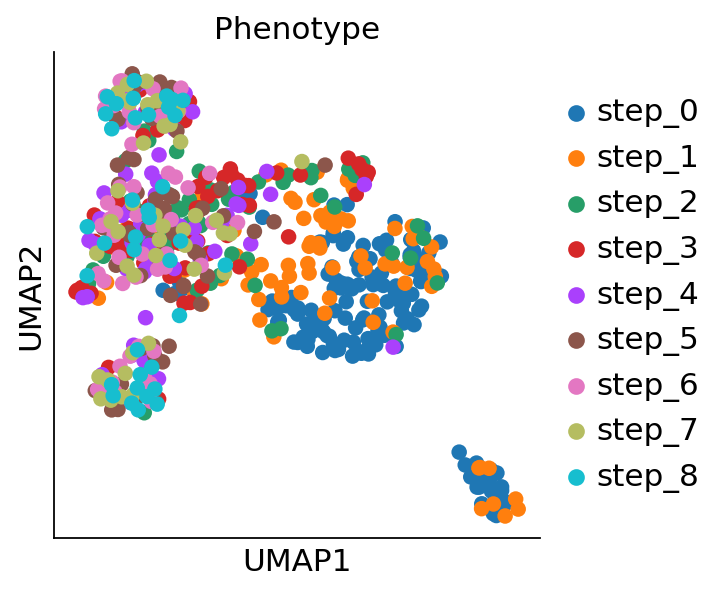

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

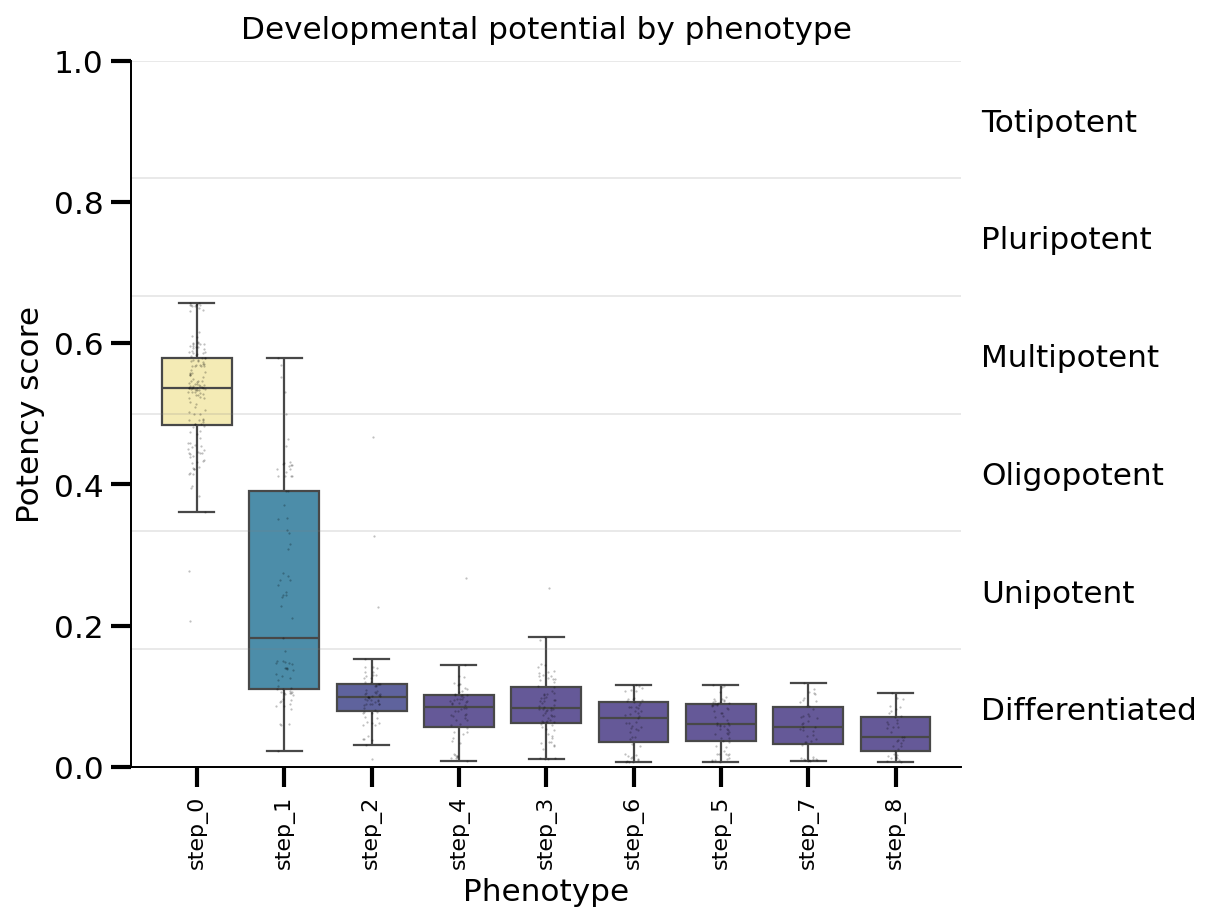

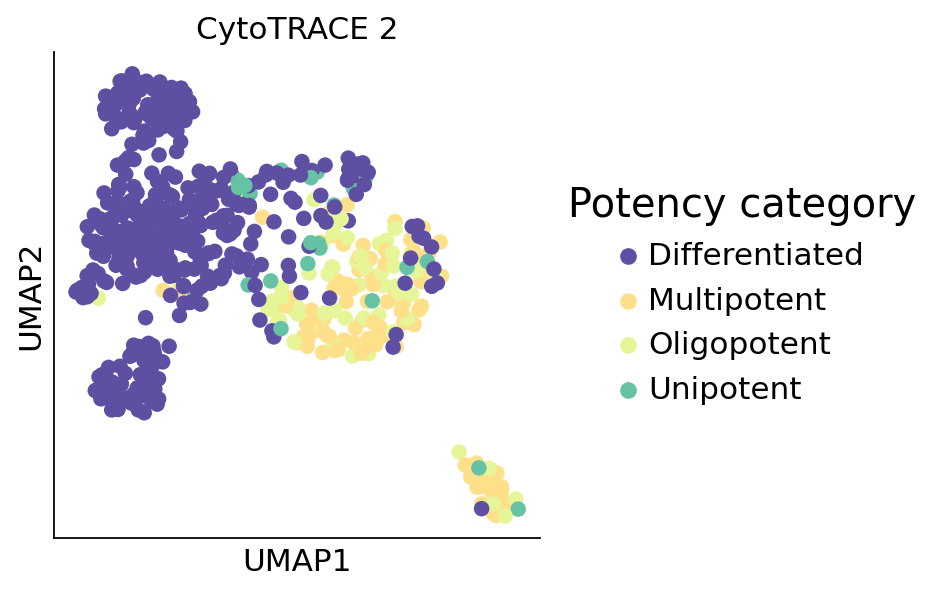

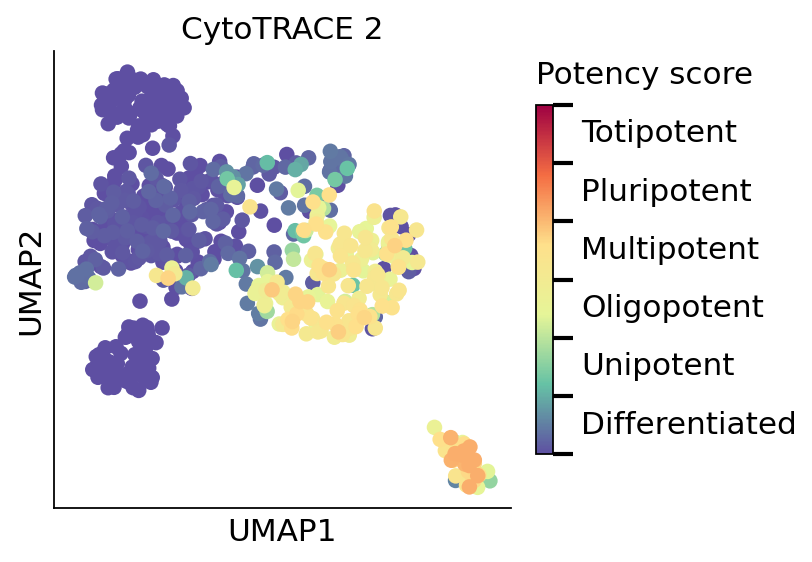

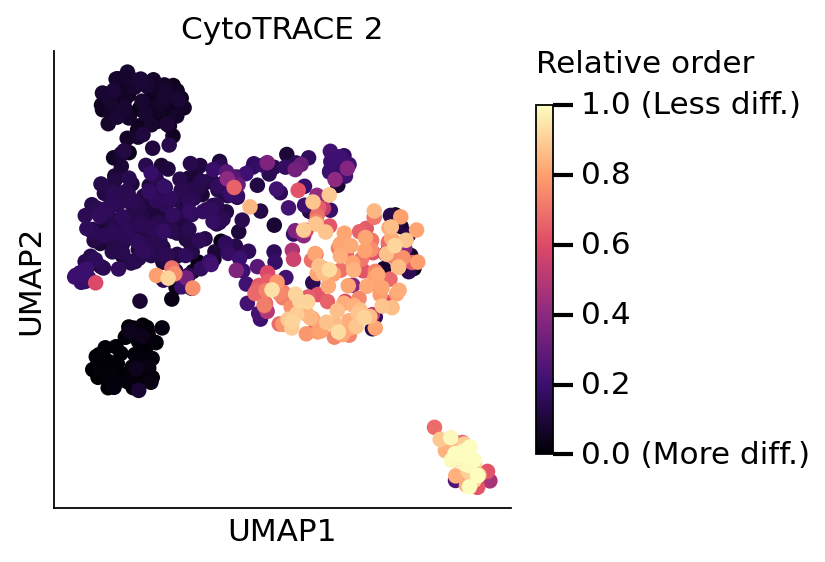

In [ ]:
input_path = f"../outputs/generated/{srx_id}/scRNA_expression_{srx_id}_traj_gt.txt"
example_annotation_path = f"../outputs/generated/{srx_id}/cell_annotation_{srx_id}_traj_gt.tsv"
example_species = "human"

results_cyto_gt = cytotrace2(input_path,
                     annotation_path=example_annotation_path,
                     species=example_species,
                     output_dir=f'../outputs/generated/{srx_id}/gt',
                     seed=28)

In [ ]:
expression = read_file(input_path)
df_anno = pd.read_csv(example_annotation_path,index_col=0,sep='\t')
adata_gt_umap = process_with_scanpy(expression, df_anno, seed=seed)
adata_gt_umap.obs = pd.concat([adata_gt_umap.obs,results_cyto_gt.loc[adata_gt_umap.obs_names,:]],axis=1)

ModuleNotFoundError: No module named 'cytotrace2_py.cytotrace2_py.common'; 'cytotrace2_py.cytotrace2_py' is not a package

<Axes: title={'center': 'time_step'}, xlabel='UMAP1', ylabel='UMAP2'>

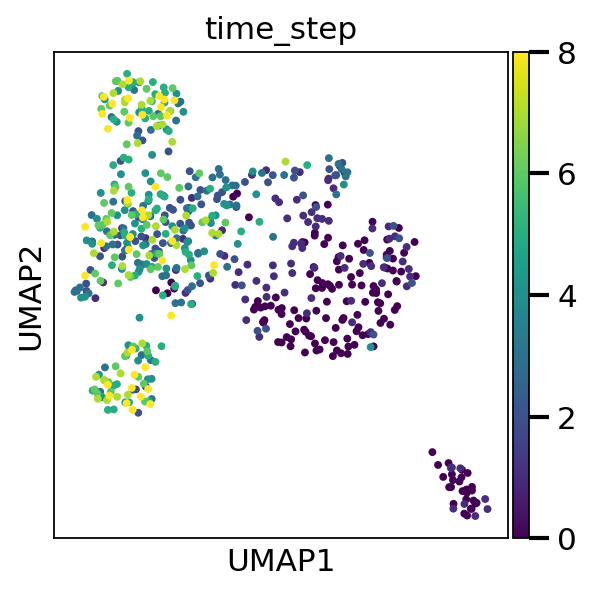

In [39]:
adata_gt_umap.obs['time_step'] = [int(pheno.split('_')[-1]) for pheno in adata_gt_umap.obs['phenotype']]
sc.pl.umap(adata_gt_umap, color='time_step', size=50, show=False)
# plt.savefig(f'figure/trajectory/{srx_id}/gt/gt_time_step.pdf', dpi=300, bbox_inches="tight")

Generated

In [40]:
adata_generated = adata_gen.copy()

# assume adata.X is a csr_matrix
X = adata_generated.X.T   # transpose: genes × cells
if not scipy.sparse.issparse(X):
    X = scipy.sparse.csr_matrix(X)

# open file stream for writing
with open(f"../outputs/generated/{srx_id}/scRNA_expression_{srx_id}_traj_gen.txt", "w") as f:
    # write header (cell names)
    header = "Gene\t" + "\t".join(adata_generated.obs_names.values)
    f.write(header + "\n")

    # write row by row (avoid converting to dense all at once)
    for i, g in enumerate(adata_generated.var_names):
        row = X.getrow(i).toarray().ravel()
        line = g + "\t" + "\t".join(map(str, row))
        f.write(line + "\n")

col = "time_step_str"

# build DataFrame
df = pd.DataFrame({
    "cell_id": adata_generated.obs_names.values,
    "phenotype": adata_generated.obs[col].values
})

# save as tab-separated txt
df.to_csv(f"../outputs/generated/{srx_id}/cell_annotation_{srx_id}_traj_gen.tsv", sep="\t", index=False)


cytotrace2: Input parameters
    Input file: ../outputs/generated/SRX12173016/scRNA_expression_SRX12173016_traj_gen.txt
    Species: human
    Parallelization enabled: True
    Batch size: 20000
    Smoothing batch size: 1000
    Seed: 14
    Output directory: ../outputs/generated/SRX12173016/gen
    Plotting enabled: True
    Verbose mode enabled: True
    User-provided limit for number of cores to use: None
       ...113 cores detected. CytoTRACE 2 will run using up to 56/113 cores.
cytotrace2: Loading dataset
cytotrace2: Dataset characteristics
    Number of input genes:  18791
    Number of input cells:  900
cytotrace2: Computing UMAP embeddings from full expression


/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.C

cytotrace2: The passed batch_size is greater than the number of cells in the subsample. 
    Now setting batch_size to 900.
cytotrace2: Preprocessing
cytotrace2: The number of cells in your dataset is less than the specified smoothing batch size.

    Model prediction will not be parallelized.
cytotrace2: Running 1 prediction batch(es) sequentially using 1 cores per batch.
cytotrace2: Initiated processing batch 1/1 with 900 cells
    Mapped 13883 input gene names to mouse orthologs
    13882 input genes are present in the model features.
cytotrace2: Performing initial model prediction
cytotrace2: Performing smoothing by diffusion
The passed subsample size is greater than the number of cells in the subsample. 
    Now setting subsample size to 900. 
cytotrace2: Performing smoothing by adaptive KNN


... storing 'phenotype' as categorical
... storing 'phenotype_txtwrap' as categorical
... storing 'preKNN_CytoTRACE2_Potency' as categorical
maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 26 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'e', 'eight', 'five', 'four', 'h', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 48, 51, 56, 66, 72, 75, 81, 82, 83, 86, 87, 92]
Closed glyph list over 'GSUB': 26 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'e', 'eight', 'five', 'four', 'h', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 48, 51, 56, 

cytotrace2: Plotting outputs


Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 48, 51, 56, 66, 72, 75, 81, 82, 83, 86, 87, 92]
Closed glyph list over 'MATH': 26 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'e', 'eight', 'five', 'four', 'h', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 48, 51, 56, 66, 72, 75, 81, 82, 83, 86, 87, 92]
Closing glyph list over 'glyf': 26 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'e', 'eight', 'five', 'four', 'h', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 48, 51, 56, 66, 72, 75, 81, 82, 83, 86, 87, 92]
Closed glyph list over 'glyf': 26 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'M', 'P', 'U', 'e', 'eight', 'five', 'four', 'h', 'n', 'no

cytotrace2: Finished.


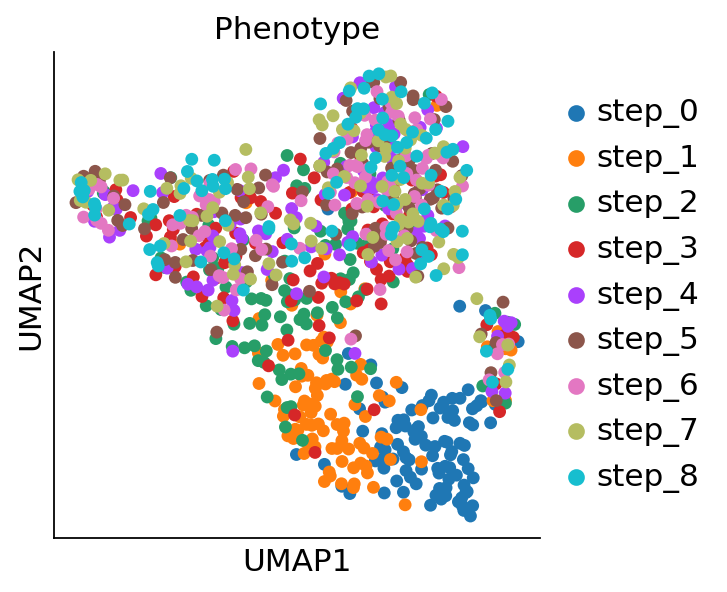

findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: 

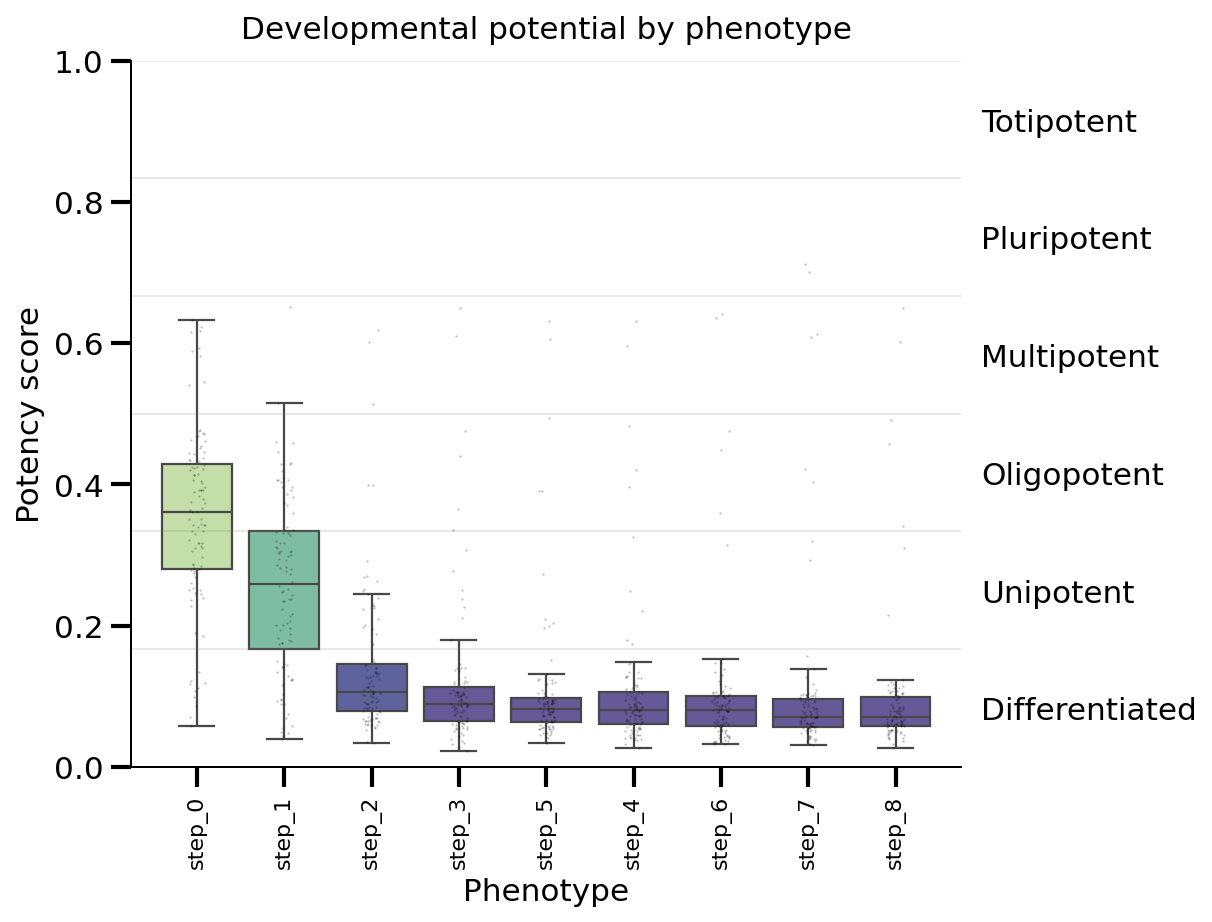

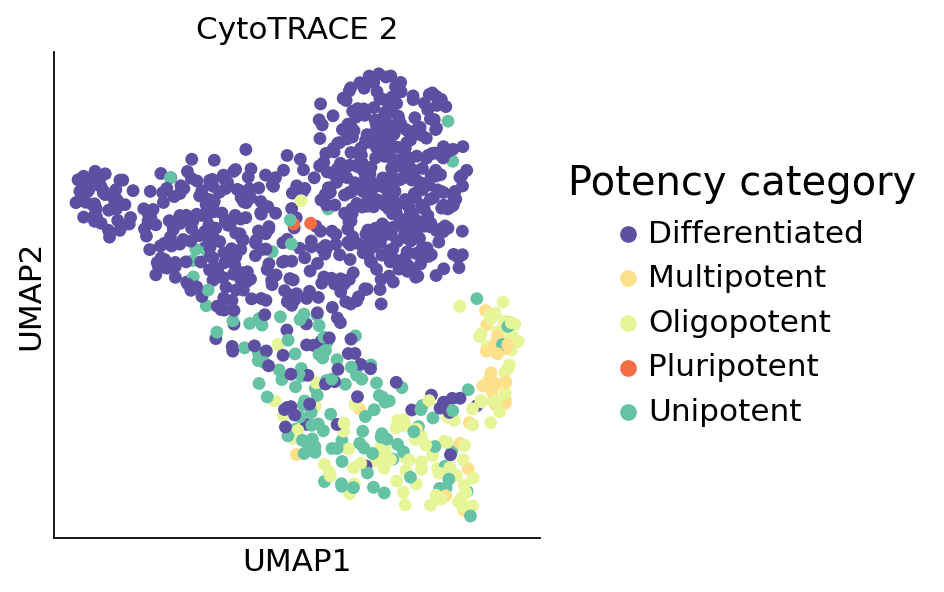

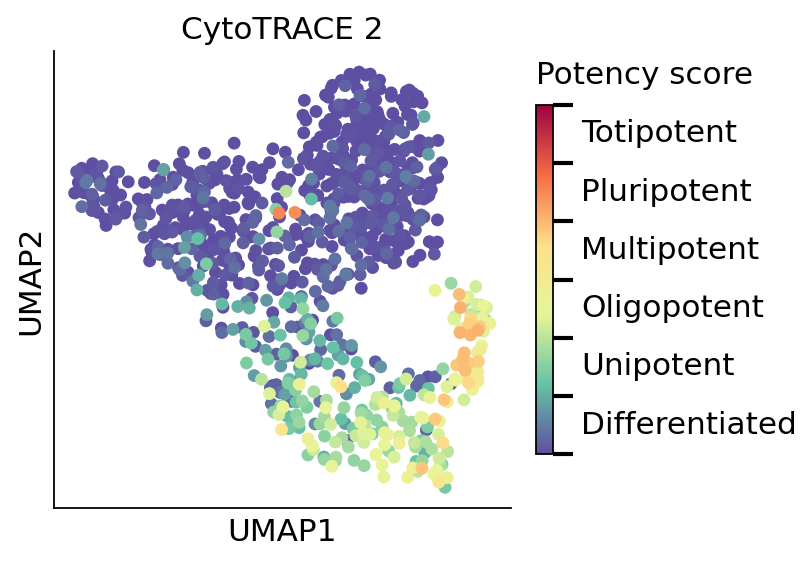

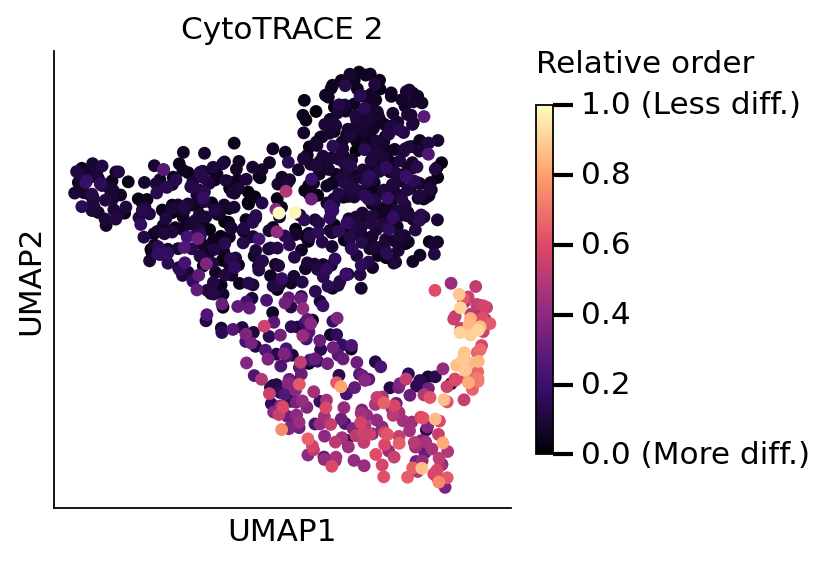

In [ ]:
input_path = f"../outputs/generated/{srx_id}/scRNA_expression_{srx_id}_traj_gen.txt"
example_annotation_path = f"../outputs/generated/{srx_id}/cell_annotation_{srx_id}_traj_gen.tsv"
example_species = "human"

results_cyto_gen = cytotrace2(input_path,
                     annotation_path=example_annotation_path,
                     species=example_species,
                     output_dir=f'../outputs/generated/{srx_id}/gen')

In [ ]:
expression = read_file(input_path)
df_anno = pd.read_csv(example_annotation_path,index_col=0,sep='\t')
adata_gen_umap = process_with_scanpy(expression, df_anno, seed=seed)
adata_gen_umap.obs = pd.concat([adata_gen_umap.obs,results_cyto_gt.loc[adata_gen_umap.obs_names,:]],axis=1)

<Axes: title={'center': 'time_step'}, xlabel='UMAP1', ylabel='UMAP2'>

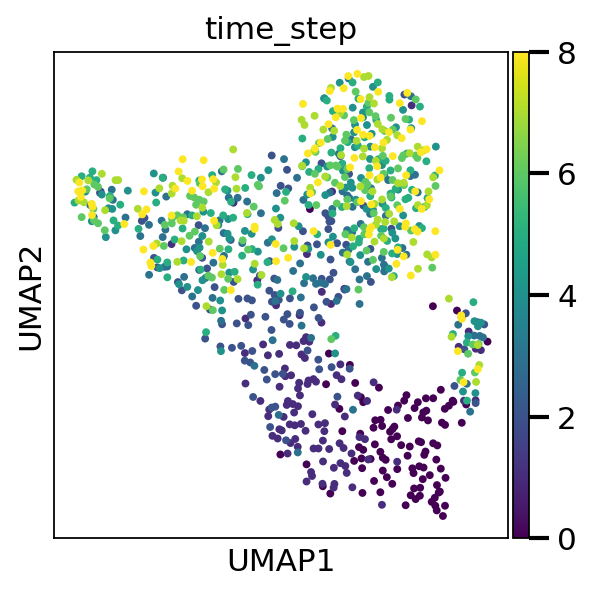

In [42]:
adata_gen_umap.obs['time_step'] = [int(pheno.split('_')[-1]) for pheno in adata_gen_umap.obs['phenotype']]
sc.pl.umap(adata_gen_umap, color='time_step', size=50, show=False)
# plt.savefig(f'figure/trajectory/{srx_id}/gen/gen_time_step.pdf', dpi=300, bbox_inches="tight")

Correlation between generated and real pseudotime

In [43]:
adata_generated.obs['pseudotime'] = (1 - results_cyto_gen['CytoTRACE2_Score']).values
pseudotime_gen_perstep = [adata_generated[adata_generated.obs['time_step']==step].obs['pseudotime'].mean() for step in np.unique(adata_generated.obs['time_step'].values)]

adata_traj_gt.obs['pseudotime'] = (1 - results_cyto_gt['CytoTRACE2_Score']).values
pseudotime_gt_perstep = [adata_traj_gt[adata_traj_gt.obs['time_step']==step].obs['pseudotime'].mean() for step in np.unique(adata_traj_gt.obs['time_step'].values)]

/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [44]:
print('pearson=',np.corrcoef(pseudotime_gen_perstep[:len(pseudotime_gt_perstep)], pseudotime_gt_perstep[:10])[0][1])
print('spearman=',stats.spearmanr(pseudotime_gen_perstep[:len(pseudotime_gt_perstep)], pseudotime_gt_perstep[:10]).correlation)

pearson= 0.978520082368203
spearman= 0.8833333333333333


# marker gene temporal dynamics

/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/tmp/ipykernel_386334/4224951466.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(tr):
/tmp/ipykernel_386334/4224951466.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(t

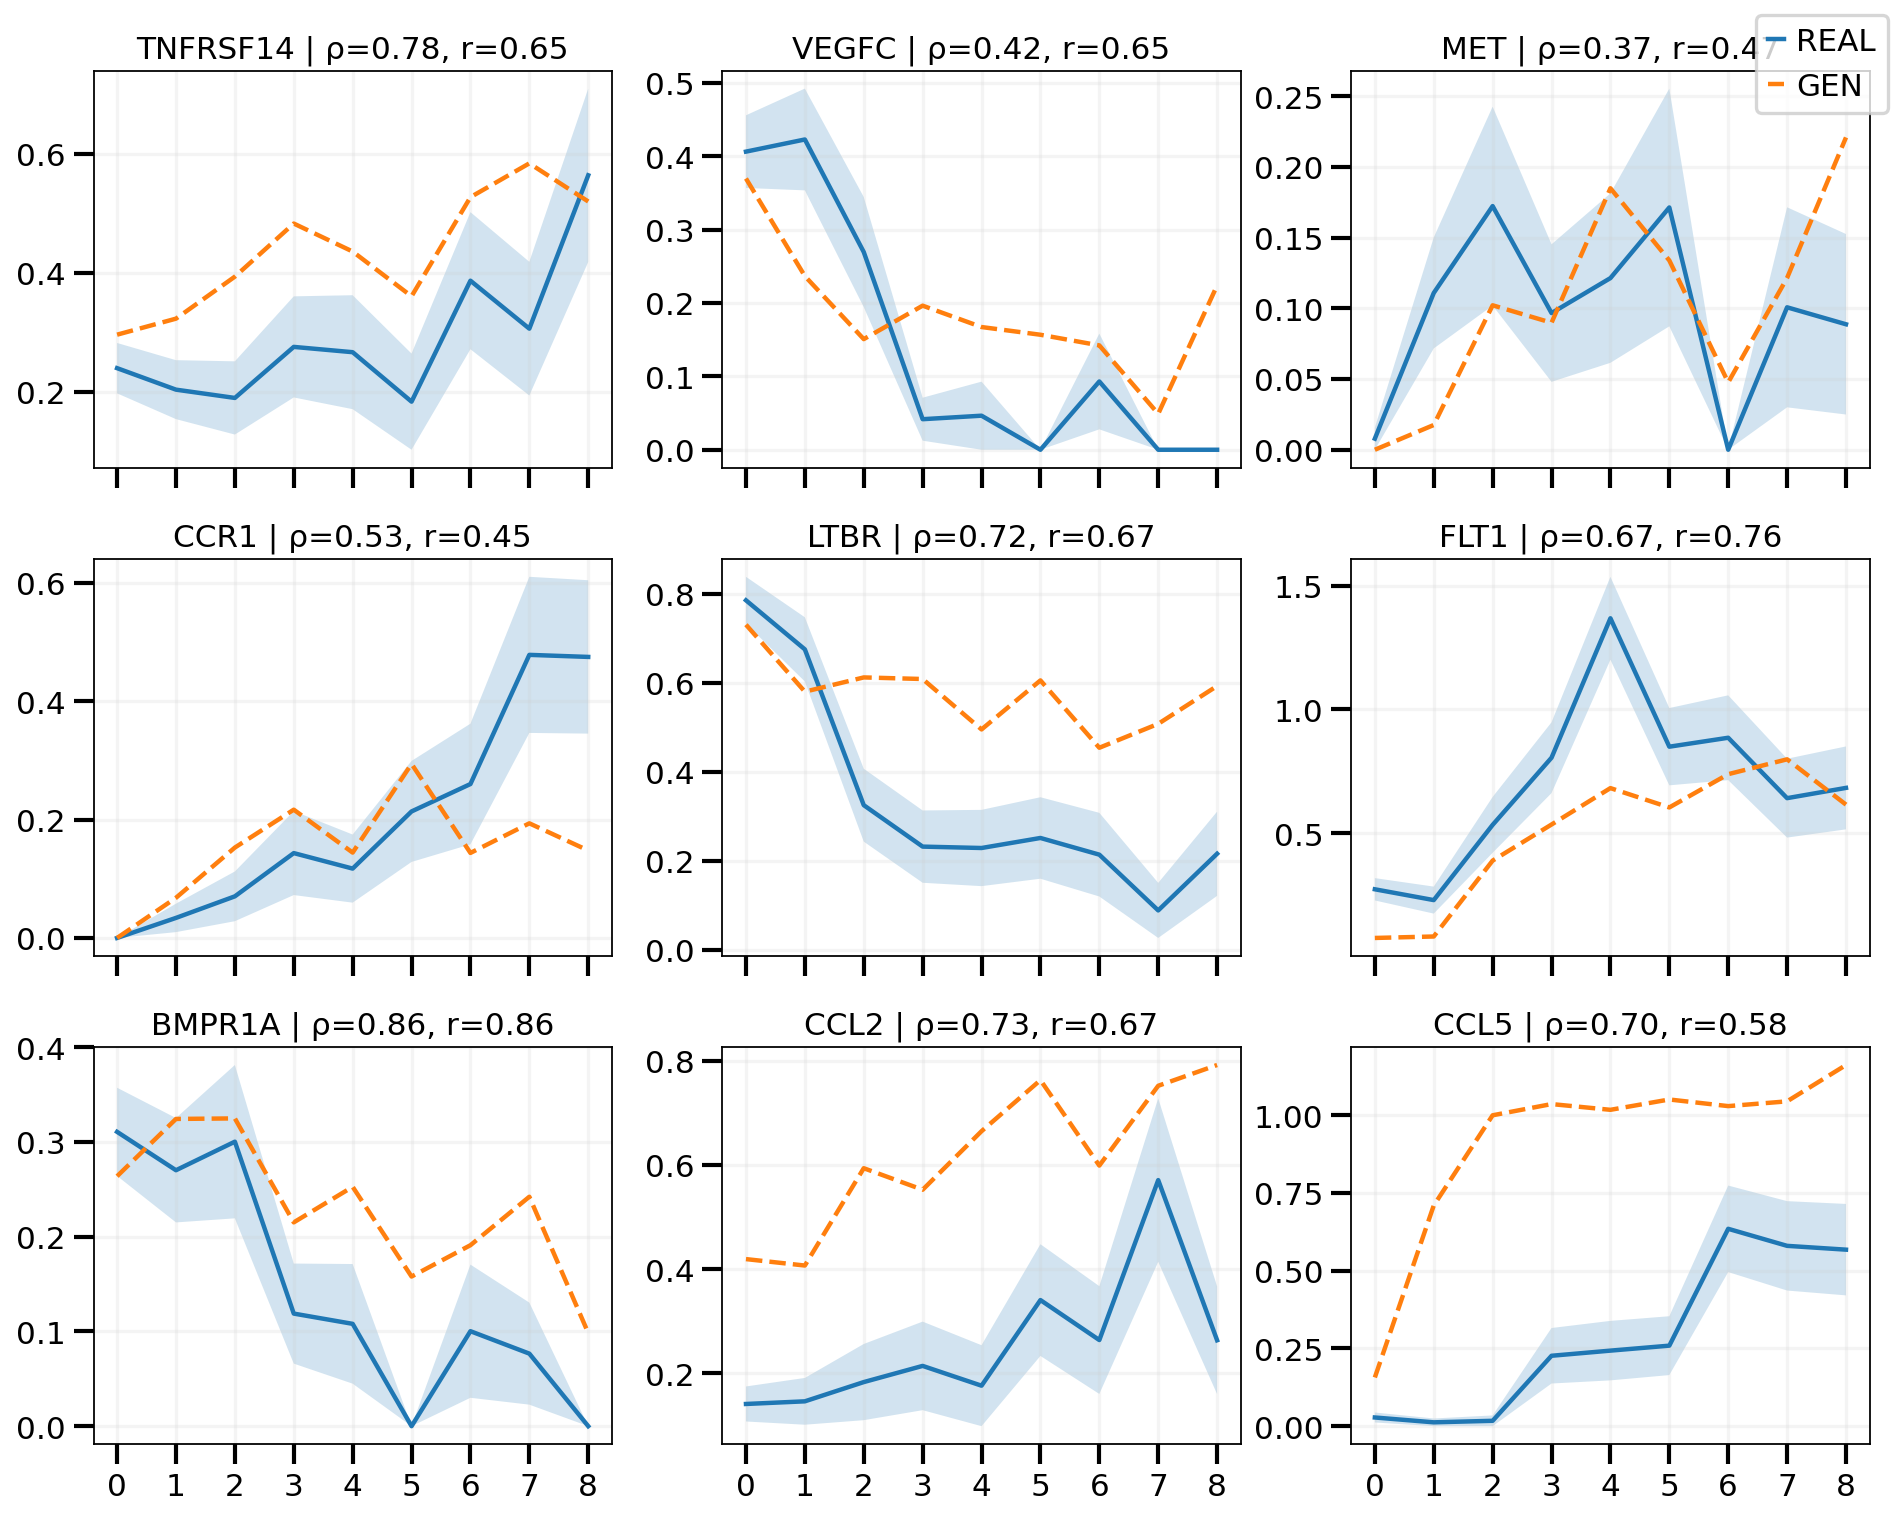

In [ ]:
marker_genes = ['WNT4', "BMP4", "TNFRSF14", "NFKBIA", "CXCR6", 'CXCL16', 'CCL5', 'VEGFC', 'CCR1'] 

corr_df, plot_markers = timecourse_markers_real_then_compare(
    adata_traj_gt,
    adata_gen,
    time_key="time_step",
    top_markers=marker_genes,
    layer=None,          # if you have a specific expression layer, specify its name
    use_spearman=True,
    use_kruskal=True,
    use_gam=True,        # skipped automatically if pygam is not installed
    gam_top=3000,
    topn_markers=30
)

# # 2) correlation table: REAL vs GEN trend correlation per marker (mean series)
# display(corr_df.head(20))

# 3) plot: compare the top 12 markers in a grid (solid=REAL, dashed=GEN)
fig = plot_markers(marker_genes, ncols=3, figsize=(12, 3.2), with_sem=True)
# plt.show()
plt.savefig(f'../outputs/generated/{srx_id}/marker.pdf')

# PAGA topology

In [43]:
adata_gt_umap.obs['time_step'] = adata_traj_gt[adata_gt_umap.obs_names].obs['time_step'].values
adata_gen_umap.obs['time_step'] = adata_generated.obs['time_step'].values
sc.tl.leiden(adata_gt_umap, key_added="leiden", resolution=0.5) #1.0  1.0  0.5
sc.tl.leiden(adata_gen_umap, key_added="leiden", resolution=1.2) #1.0  0.5  1.2

In [44]:
adata_gt_umap.obs['pseudotime'] = 1 - adata_gt_umap.obs['CytoTRACE2_Score']
adata_gen_umap.obs['pseudotime'] = 1 - adata_gen_umap.obs['CytoTRACE2_Score']

In [ ]:
adata_gen_umap,adata_gt_umap

(AnnData object with n_obs × n_vars = 900 × 13121
     obs: 'phenotype', 'phenotype_txtwrap', 'n_genes', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency', 'CytoTRACE2_Score_Phenotype_Median', 'CytoTRACE2_Score_Plot', 'time_step', 'leiden'
     var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
     uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'phenotype_txtwrap_colors', 'CytoTRACE2_Potency_colors', 'leiden'
     obsm: 'X_pca', 'X_umap'
     varm: 'PCs'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 820 × 13473
     obs: 'phenotype', 'phenotype_txtwrap', 'n_genes', 'CytoTRACE2_Score', 'CytoTRACE2_Potency', 'CytoTRACE2_Relative', 'preKNN_CytoTRACE2_Score', 'preKNN_CytoTRACE2_Potency', 'CytoTRACE2_Score_Phenotype_Median', 'CytoTRACE2_Score_Plot', 'time_step', 'leiden'
     var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersio

In [ ]:
abs_path = Path(f'../outputs/generated/{srx_id}').resolve().as_posix()
analysis_topo(adata_gt_umap,adata_gen_umap,'leiden',abs_path,paga_threshold=0.12, use_elpi=False, pt_key="pseudotime")

maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'GSUB': 40 glyphs before
Glyph names: ['.notdef', '.null', 'A', 'E', 'G', 'L', 'M', 'N', 'P', 'R', 'U', 'a', 'c', 'colon', 'd', 'e', 'eight', 'five', 'four', 'i', 'j', 'm', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'two', 'u', 'y', 'zero']
Glyph IDs:   [0, 1, 2, 3, 11, 12, 17, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 36, 40, 42, 47, 48, 49, 51, 53, 56, 68, 70, 71, 72, 76, 77, 80, 82, 83, 85, 86, 87, 88, 92]
Closed glyph list over 'GSUB': 40 glyphs after
Glyph names: ['.notdef', '.null', 'A', 'E', 'G', 'L', 'M', 'N', 'P', 'R', 'U', 'a', 'c', 'colon', 'd', 'e', 'eight', 'five', 'four', 'i', 'j', 'm', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'two', 'u', 'y',

# composition analysis

In [56]:
from utils_metrics import celltype_composition_pipeline

In [114]:
tissue

'uterus'

In [58]:
from celltypist import models

# view all official model names
models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
5,Adult_Human_PancreaticIslet.pkl,cell types from pancreatic islets of healthy a...
6,Adult_Human_PrefrontalCortex.pkl,cell types and subtypes from the adult human d...
7,Adult_Human_Skin.pkl,cell types from human healthy adult skin
8,Adult_Human_Vascular.pkl,vascular populations combined from multiple ad...
9,Adult_Mouse_Gut.pkl,cell types in the adult mouse gut combined fro...


/tmp/ipykernel_386334/3345043274.py:162: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[label_col].dtype):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
📂 Storing models in /root/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Human_Endometrium_Atlas.pkl (file exists)
🔬 Input data has 149 cells and 18791 genes
🔗 Matching reference genes in the model


[CellTypist] Annotating REAL ...
[CellTypist] Annotating step=0 (n=149) ...


🧬 3578 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3

[CellTypist] Annotating step=1 (n=102) ...


🧬 3578 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3

...

🧬 3578 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3

[CellTypist] Annotating step=7 (n=58) ...


🧬 3578 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3

[CellTypist] Annotating step=8 (n=57) ...


🧬 3578 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3/lib/python3.10/site-packages/anndata/_core/anndata.py:1113: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/root/miniconda3

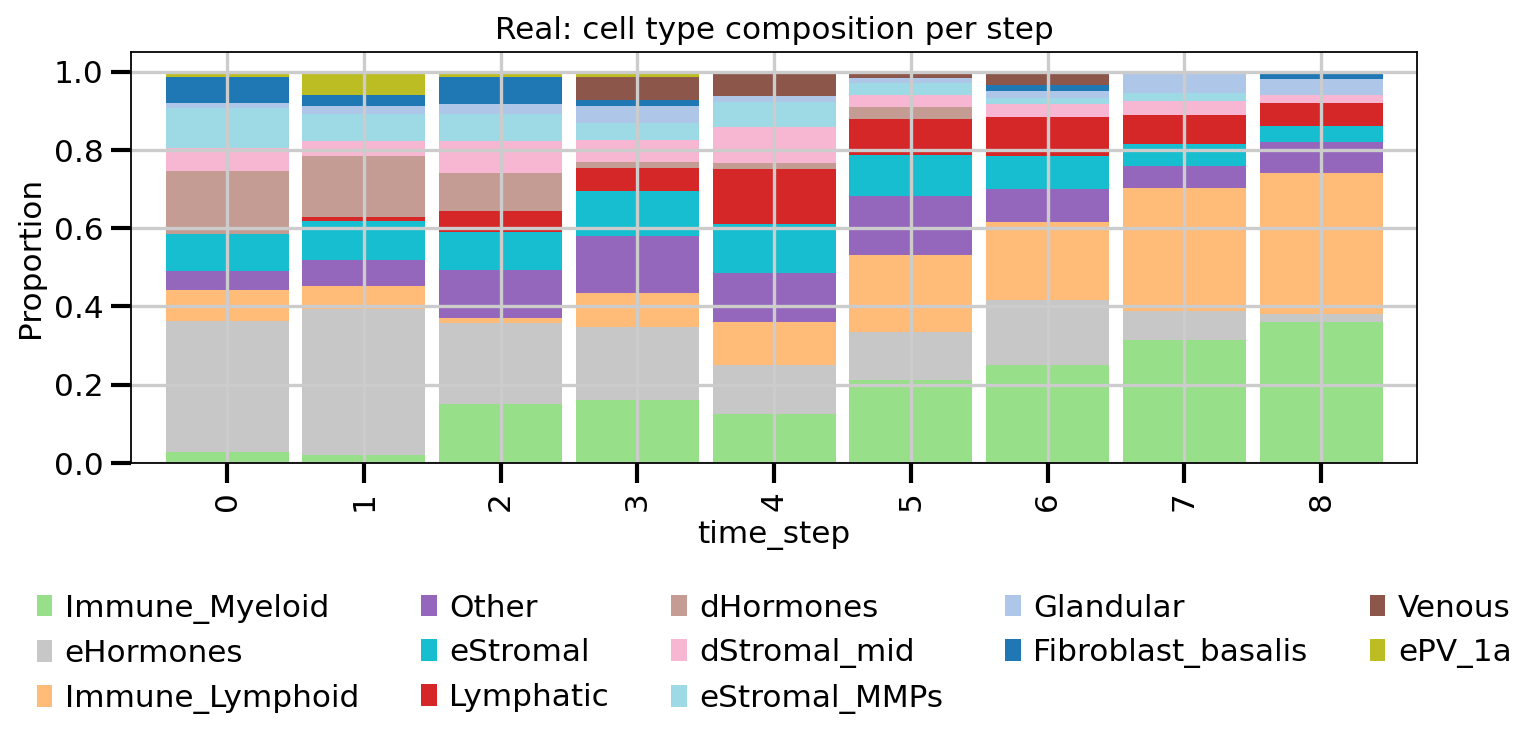

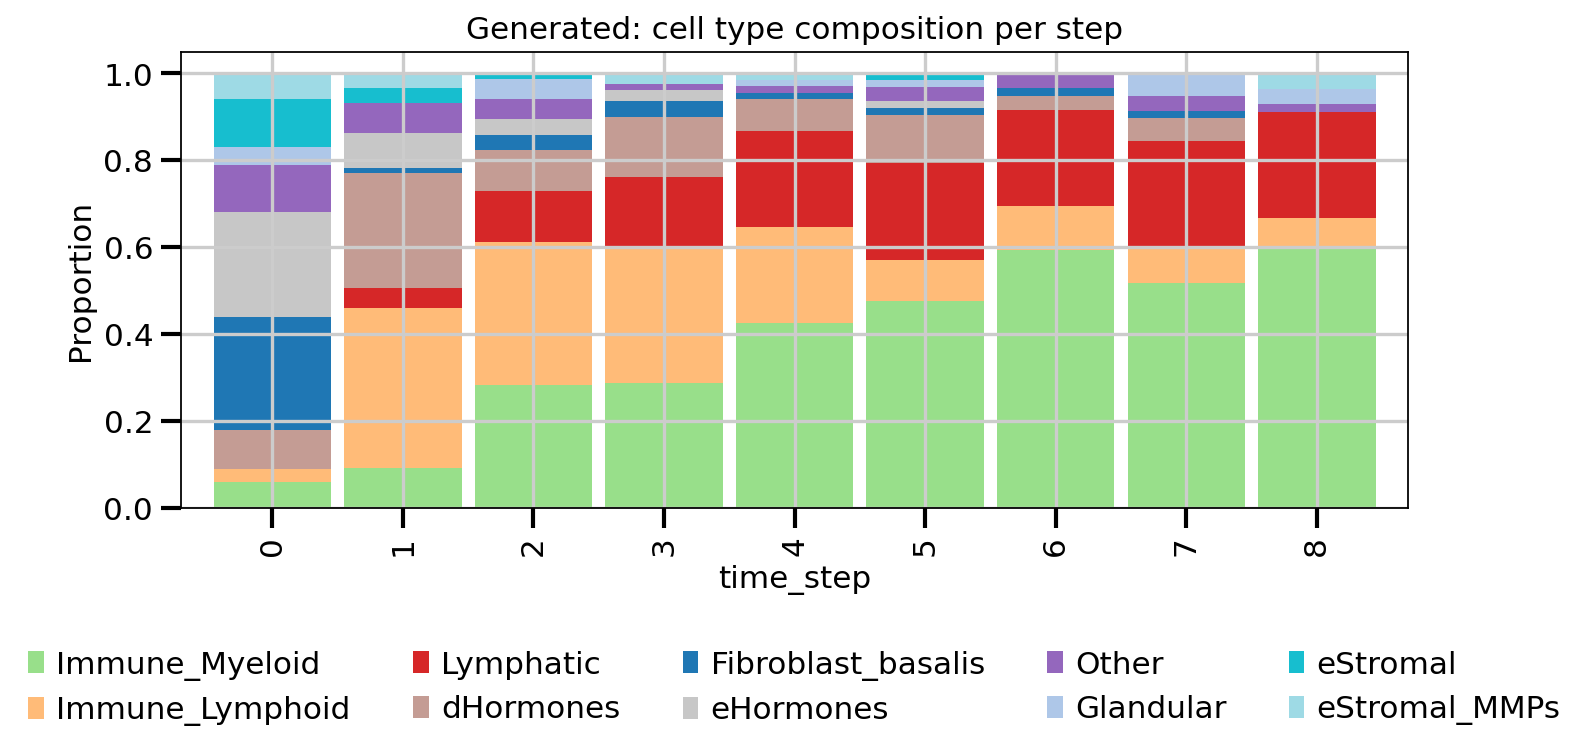

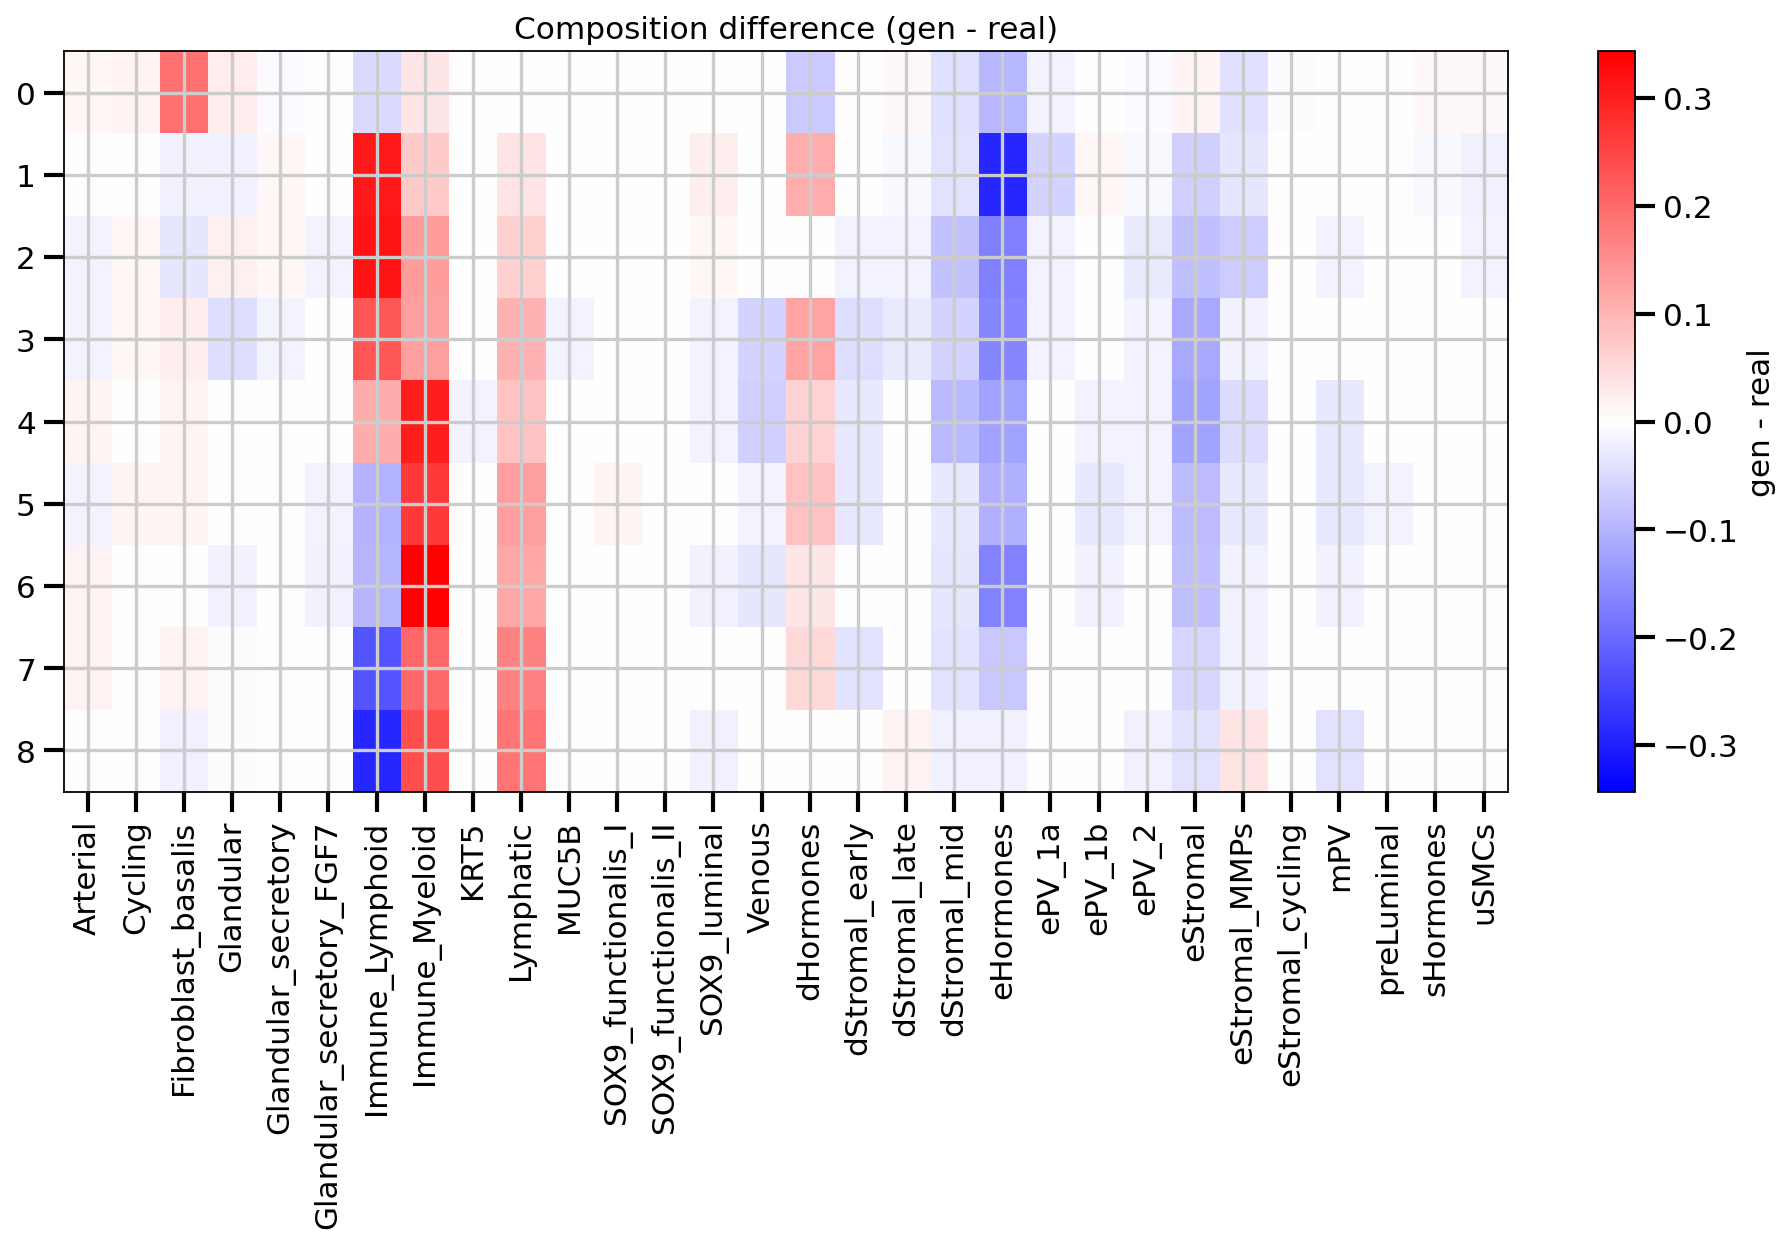

[Export] Exported to prefix figure/trajectory/SRX12173003/traj_cmp_celltypist_*.csv


In [ ]:
abs_path = Path(f'../outputs/generated/{srx_id}').resolve().as_posix() + '/traj_cmp_celltypist'
# ================== Usage example ==================
res = celltype_composition_pipeline(adata_traj_gt, adata_gen, #adata_gt_umap,adata_gen_umap,
                                    model_name='Human_Endometrium_Atlas.pkl',#'Immune_All_Low.pkl',#'Developing_Human_Organs.pkl',
                                    step_candidates=('time_step', 'time_step_str'),
                                    export_prefix=abs_path)

In [ ]:
df = pd.read_csv(abs_path + '_JSD_by_step.csv',index_col=0)
df['JSD'].mean()

0.21119487439499396